In [ ]:
# Install and import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("✅ All libraries ready!")

✅ All libraries ready!


In [ ]:
# Generate the dataset
np.random.seed(42)
n = 1000

sqft_living = np.random.normal(1800, 600, n).clip(600, 5000).astype(int)
bedrooms    = np.random.randint(1, 7, n)
bathrooms   = np.round(np.random.uniform(1, 4, n) * 2) / 2
house_age   = np.random.randint(0, 81, n)
lot_size    = np.random.normal(7500, 3000, n).clip(2000, 20000).astype(int)
floors      = np.random.choice([1, 1.5, 2, 3], n, p=[0.3, 0.2, 0.4, 0.1])
garage      = np.random.randint(0, 4, n)
location    = np.random.choice(['Urban', 'Suburban', 'Rural'], n, p=[0.35, 0.45, 0.20])
school_rating = np.random.choice(['Poor', 'Average', 'Good', 'Excellent'], n, p=[0.10, 0.30, 0.40, 0.20])

location_score = {'Urban': 1.30, 'Suburban': 1.10, 'Rural': 0.85}
school_score   = {'Poor': 0.90, 'Average': 1.00,'Good': 1.10, 'Excellent': 1.25}


price = (80 * sqft_living + bedrooms*8000 + bathrooms*12000
         - house_age*1500 + lot_size*2 + garage*10000 + floors*15000)
price = price * np.array([location_score[l] for l in location])
price = price * np.array([school_score[s]  for s in school_rating])
price = price * np.random.normal(1.0, 0.10, n)
price = np.round(price / 1000) * 1000
price = price.clip(50000, 1500000)

df = pd.DataFrame({
    'sqft_living': sqft_living.astype(float),
    'bedrooms': bedrooms.astype(float),
    'bathrooms': bathrooms,
    'house_age': house_age.astype(float),
    'lot_size': lot_size.astype(float),
    'floors': floors,
    'garage': garage.astype(float),
    'location': location,
    'school_rating': school_rating,
    'price': price
})

print(f"✅ Dataset created: {df.shape}")
print(df.head())

✅ Dataset created: (1000, 10)
   sqft_living  bedrooms  bathrooms  house_age  lot_size  floors  garage  \
0       2098.0       4.0        2.5       56.0    3559.0     2.0     0.0   
1       1717.0       1.0        3.0       80.0   10061.0     2.0     0.0   
2       2188.0       3.0        3.5       33.0    5833.0     1.0     2.0   
3       2713.0       5.0        1.5       40.0    4884.0     2.0     3.0   
4       1659.0       3.0        2.0       72.0    6912.0     1.0     3.0   

   location school_rating     price  
0     Rural     Excellent  208000.0  
1     Rural       Average   96000.0  
2     Urban          Good  383000.0  
3  Suburban       Average  347000.0  
4     Urban          Good  182000.0  


In [ ]:
# DATA CLEANING
# Handle missing values
for col in ['sqft_living', 'bathrooms', 'house_age']:
    df[col].fillna(df[col].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Fix data types
df['bedrooms'] = df['bedrooms'].astype(int)
df['garage']   = df['garage'].astype(int)

print("✅ Data Cleaning Done!")
print(f"Total rows: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Data types:\n{df.dtypes}")

✅ Data Cleaning Done!
Total rows: 1000
Missing values: 0
Data types:
sqft_living      float64
bedrooms           int64
bathrooms        float64
house_age        float64
lot_size         float64
floors           float64
garage             int64
location          object
school_rating     object
price            float64
dtype: object


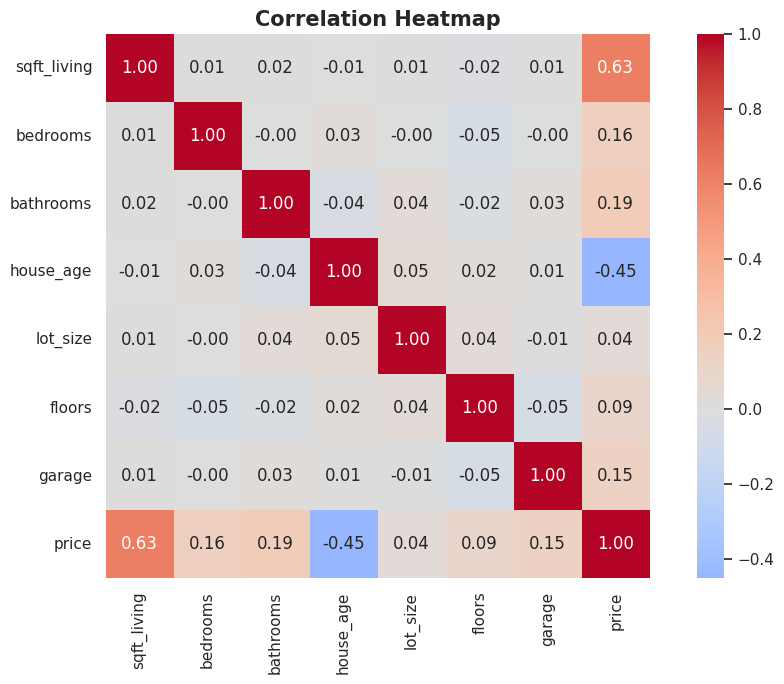

✅ Heatmap done!


In [ ]:
# EDA - Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Heatmap done!")

In [ ]:

# Reimport to fix the error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

le = LabelEncoder()

# FEATURE ENGINEERING
df['location_enc']      = le.fit_transform(df['location'])
df['school_rating_enc'] = le.fit_transform(df['school_rating'])
df['total_rooms']       = df['bedrooms'] + df['bathrooms']
df['condition_index']   = (80 - df['house_age']) / 80 + df['floors'] * 0.1

print("✅ Features engineered!")

# MODEL BUILDING
feature_cols = ['sqft_living', 'bedrooms', 'bathrooms', 'house_age',
                'lot_size', 'floors', 'garage', 'location_enc',
                'school_rating_enc', 'total_rooms', 'condition_index']

X = df[feature_cols]
y = df['price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


✅ Features engineered!
✅ Model trained!
Training samples : 800
Testing  samples : 200


In [ ]:
# MODEL EVALUATION
y_pred = model.predict(X_test)

MAE  = mean_absolute_error(y_test, y_pred)
MSE  = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2   = r2_score(y_test, y_pred)

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error) : ${MAE:,.2f}")
print(f"  MSE  (Mean Squared Error)  : ${MSE:,.2f}")
print(f"  RMSE (Root Mean Sq Error)  : ${RMSE:,.2f}")
print(f"  R²   (R-Squared Score)     :  {R2:.4f}")
print("=" * 45)
print(f"  Model explains {R2*100:.1f}% of price variance")
print(f"  Average prediction error = ${MAE:,.0f}")

       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error) : $30,040.23
  MSE  (Mean Squared Error)  : $1,687,221,839.89
  RMSE (Root Mean Sq Error)  : $41,075.81
  R²   (R-Squared Score)     :  0.8234
  Model explains 82.3% of price variance
  Average prediction error = $30,040


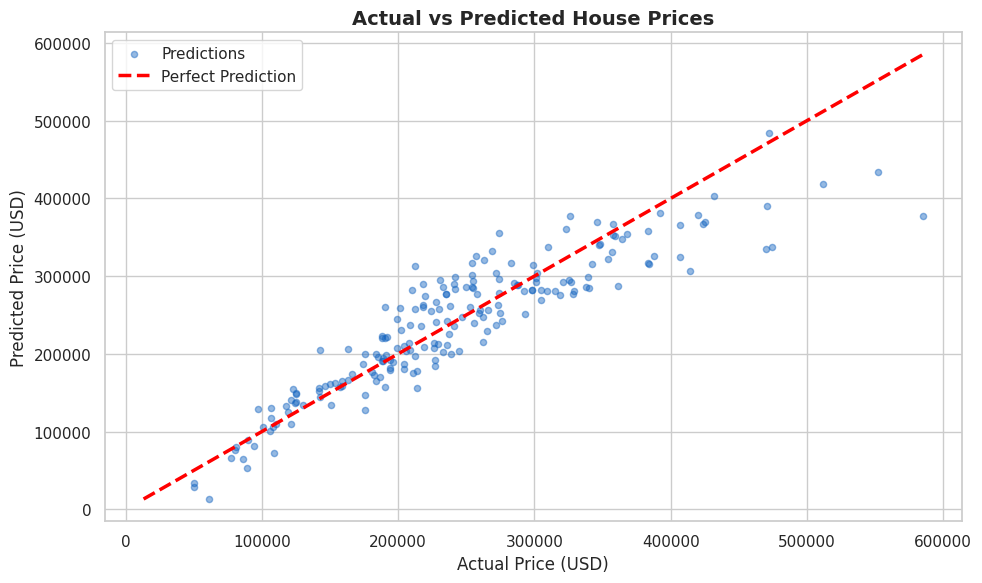

✅ Chart done!


In [ ]:
# VISUALIZATION - Actual vs Predicted
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.45, color='#1565C0', s=20, label='Predictions')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2.5, linestyle='--', label='Perfect Prediction')

plt.title("Actual vs Predicted House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Chart done!")

In [ ]:
# PREDICT NEW HOUSE PRICES
new_houses = pd.DataFrame({
    'sqft_living'      : [1200, 2200, 3500, 850,  2800],
    'bedrooms'         : [2,    3,    5,    1,    4   ],
    'bathrooms'        : [1.5,  2.0,  3.5,  1.0,  3.0 ],
    'house_age'        : [30,   10,   5,    50,   1   ],
    'lot_size'         : [5000, 8000, 12000,3000, 9500 ],
    'floors'           : [1,    2,    2,    1,    3   ],
    'garage'           : [1,    2,    3,    0,    2   ],
    'location_enc'     : [2,    1,    2,    0,    1   ],
    'school_rating_enc': [1,    2,    3,    0,    3   ],
    'total_rooms'      : [3.5,  5.0,  8.5,  2.0,  7.0 ],
    'condition_index'  : [0.76, 0.91, 0.94, 0.54, 1.00]
})

predictions = model.predict(new_houses)

houses = ["Small Urban Condo", "Mid-Range Suburban",
          "Large Urban Family", "Tiny Rural Cottage", "Luxury New Build"]

print("=" * 45)
print("      HOUSE PRICE PREDICTIONS")
print("=" * 45)
for house, pred in zip(houses, predictions):
    print(f"  {house:<22} : ${pred:>10,.0f}")
print("=" * 45)
print("✅ Predictions complete!")

      HOUSE PRICE PREDICTIONS
  Small Urban Condo      : $   186,644
  Mid-Range Suburban     : $   320,030
  Large Urban Family     : $   554,449
  Tiny Rural Cottage     : $    -1,427
  Luxury New Build       : $   438,424
✅ Predictions complete!
